In [15]:
from google.colab import drive
drive.mount('/content/drive')

import tensorflow as tf
from tensorflow.keras import layers, models, callbacks
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications import efficientnet

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [16]:
#

IMG_SIZE = (224, 224)
BATCH_SIZE = 32
SEED = 42

DATASET_PATH = "/content/drive/MyDrive/Garbage-Classification/datasets"

# Verify the dataset exists
import os
assert os.path.exists(DATASET_PATH), f"Dataset path not found: {DATASET_PATH}"

train_ds = tf.keras.utils.image_dataset_from_directory(
    DATASET_PATH,
    validation_split=0.2,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical"
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    DATASET_PATH,
    validation_split=0.2,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical"
)

class_names = train_ds.class_names
num_classes = len(class_names)

print("Classes:", class_names)
print("Number of classes:", num_classes)

AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.shuffle(1000).prefetch(AUTOTUNE)
val_ds = val_ds.prefetch(AUTOTUNE)

Found 2527 files belonging to 6 classes.
Using 2022 files for training.
Found 2527 files belonging to 6 classes.
Using 505 files for validation.
Classes: ['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']
Number of classes: 6


In [17]:
# Data Augmentation

data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.2),
    layers.RandomZoom(0.2),
    layers.RandomContrast(0.2),
])

In [19]:
# Build the Model (EfficientNetB0)

# Load pretrained EfficientNetB0
base_model = EfficientNetB0(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

# Freeze the base model
base_model.trainable = False

# Build the model
inputs = tf.keras.Input(shape=(224, 224, 3))

x = data_augmentation(inputs)
x = efficientnet.preprocess_input(x)

x = base_model(x, training=False)

x = layers.GlobalAveragePooling2D()(x)
x = layers.BatchNormalization()(x)

x = layers.Dense(512, activation="relu")(x)
x = layers.Dropout(0.4)(x)

x = layers.Dense(256, activation="relu")(x)
x = layers.Dropout(0.3)(x)

outputs = layers.Dense(num_classes, activation="softmax")(x)

model = models.Model(inputs, outputs)

model.summary()

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │       655,872 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 6)              │         1,542 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,843,433 (18.48 MB)

 Trainable params: 791,302 (3.02 MB)

 Non-trainable params: 4,052,131 (15.46 MB)

In [20]:
# Compile Model

model.compile(
    optimizer=tf.keras.optimizers.AdamW(
        learning_rate=1e-3,
        weight_decay=1e-4
    ),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

In [21]:
# Callbacks

callbacks_list = [
    callbacks.ModelCheckpoint(
        "best_model.keras",
        monitor="val_accuracy",
        save_best_only=True,
        verbose=1
    ),

    callbacks.EarlyStopping(
        monitor="val_accuracy",
        patience=5,
        restore_best_weights=True
    ),

    callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.2,
        patience=2,
        min_lr=1e-7,
        verbose=1
    )
]

In [22]:
#  Initial Training

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15,
    callbacks=callbacks_list
)

Epoch 1/15
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step - accuracy: 0.5774 - loss: 1.2151
Epoch 1: val_accuracy improved from None to 0.85149, saving model to best_model.keras

Epoch 1: finished saving model to best_model.keras
64/64 ━━━━━━━━━━━━━━━━━━━━ 338s 1s/step - accuracy: 0.6894 - loss: 0.9205 - val_accuracy: 0.8515 - val_loss: 0.5543 - learning_rate: 0.0010
Epoch 2/15
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step - accuracy: 0.8115 - loss: 0.5467
Epoch 2: val_accuracy did not improve from 0.85149
64/64 ━━━━━━━━━━━━━━━━━━━━ 13s 118ms/step - accuracy: 0.8061 - loss: 0.5696 - val_accuracy: 0.8455 - val_loss: 0.4815 - learning_rate: 0.0010
Epoch 3/15
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step - accuracy: 0.8422 - loss: 0.4361
Epoch 3: val_accuracy improved from 0.85149 to 0.87327, saving model to best_model.keras

Epoch 3: finished saving model to best_model.keras
64/64 ━━━━━━━━━━━━━━━━━━━━ 15s 136ms/step - accuracy: 0.8417 - loss: 0.4426 - val_accuracy: 0.8733 - val_loss: 0.3758 - learning_rate

In [23]:
# Fine Tuning

# Unfreeze the base model
base_model.trainable = True

# Freeze most layers, train only the last 30
for layer in base_model.layers[:-30]:
    layer.trainable = False

# Recompile with a smaller learning rate
model.compile(
    optimizer=tf.keras.optimizers.AdamW(
        learning_rate=1e-5,
        weight_decay=1e-4
    ),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

history_finetune = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    callbacks=callbacks_list
)

Epoch 1/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step - accuracy: 0.8525 - loss: 0.4293
Epoch 1: val_accuracy did not improve from 0.88317
64/64 ━━━━━━━━━━━━━━━━━━━━ 33s 175ms/step - accuracy: 0.8501 - loss: 0.4313 - val_accuracy: 0.8792 - val_loss: 0.3273 - learning_rate: 1.0000e-05
Epoch 2/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step - accuracy: 0.8557 - loss: 0.3992
Epoch 2: val_accuracy did not improve from 0.88317
64/64 ━━━━━━━━━━━━━━━━━━━━ 16s 132ms/step - accuracy: 0.8556 - loss: 0.3977 - val_accuracy: 0.8792 - val_loss: 0.3293 - learning_rate: 1.0000e-05
Epoch 3/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step - accuracy: 0.8641 - loss: 0.3856
Epoch 3: val_accuracy did not improve from 0.88317

Epoch 3: ReduceLROnPlateau reducing learning rate to 1.9999999494757505e-06.
64/64 ━━━━━━━━━━━━━━━━━━━━ 15s 120ms/step - accuracy: 0.8640 - loss: 0.3865 - val_accuracy: 0.8772 - val_loss: 0.3354 - learning_rate: 1.0000e-05
Epoch 4/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step - accuracy: 0.8731 - loss

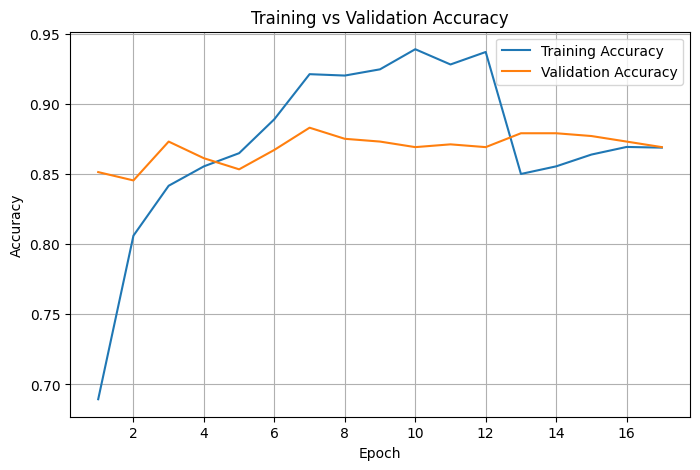

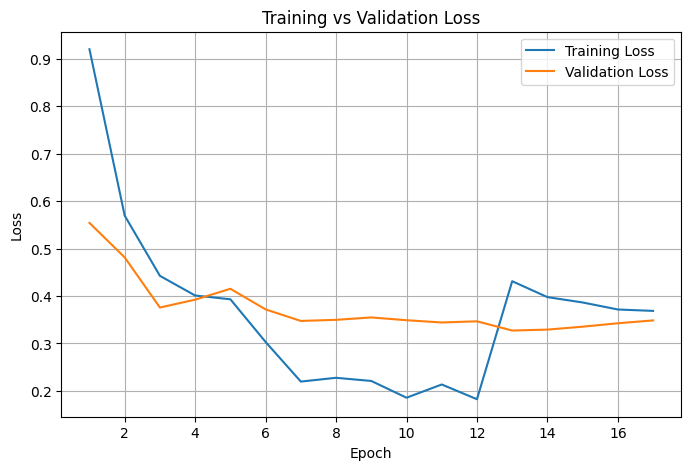

In [24]:
# Plot Training History

import matplotlib.pyplot as plt

# Combine histories
train_acc = history.history["accuracy"] + history_finetune.history["accuracy"]
val_acc = history.history["val_accuracy"] + history_finetune.history["val_accuracy"]

train_loss = history.history["loss"] + history_finetune.history["loss"]
val_loss = history.history["val_loss"] + history_finetune.history["val_loss"]

epochs = range(1, len(train_acc) + 1)

# Accuracy Plot
plt.figure(figsize=(8,5))
plt.plot(epochs, train_acc, label="Training Accuracy")
plt.plot(epochs, val_acc, label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.grid(True)
plt.show()

# Loss Plot
plt.figure(figsize=(8,5))
plt.plot(epochs, train_loss, label="Training Loss")
plt.plot(epochs, val_loss, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

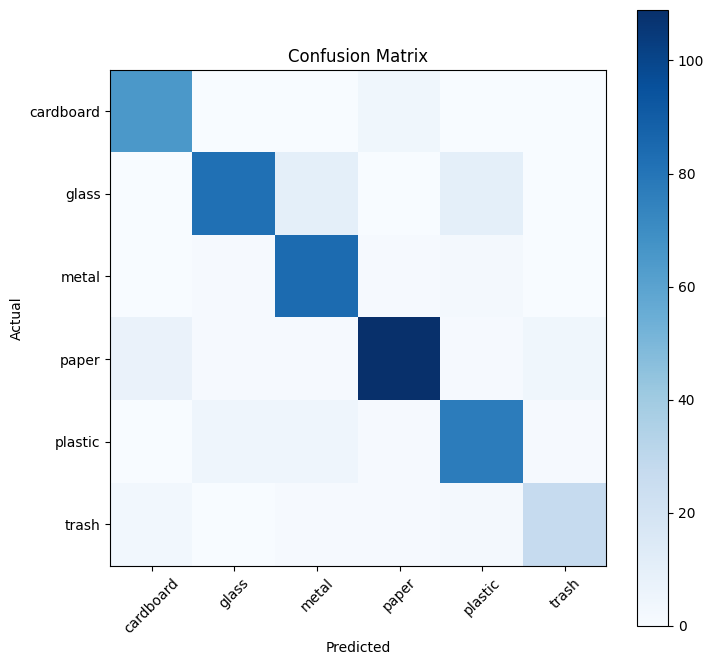

              precision    recall  f1-score   support

   cardboard       0.87      0.94      0.90        69
       glass       0.92      0.80      0.86       102
       metal       0.83      0.95      0.89        88
       paper       0.94      0.89      0.91       123
     plastic       0.84      0.87      0.85        89
       trash       0.84      0.79      0.82        34

    accuracy                           0.88       505
   macro avg       0.87      0.87      0.87       505
weighted avg       0.88      0.88      0.88       505



In [25]:
# Confusion Matrix & Classification Report

import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt

y_true = []
y_pred = []

for images, labels in val_ds:
    predictions = model.predict(images, verbose=0)
    y_true.extend(np.argmax(labels.numpy(), axis=1))
    y_pred.extend(np.argmax(predictions, axis=1))

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8,8))
plt.imshow(cm, interpolation="nearest", cmap="Blues")
plt.title("Confusion Matrix")
plt.colorbar()

tick_marks = np.arange(len(class_names))
plt.xticks(tick_marks, class_names, rotation=45)
plt.yticks(tick_marks, class_names)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

print(classification_report(
    y_true,
    y_pred,
    target_names=class_names
))

In [27]:
# Save Model

MODEL_PATH = "/content/drive/MyDrive/Garbage-Classification/saved_model/garbage_classifier.keras"

model.save(MODEL_PATH)

print("Model saved successfully!")
print(MODEL_PATH)

Model saved successfully!
/content/drive/MyDrive/Garbage-Classification/saved_model/garbage_classifier.keras


In [29]:
# Save Class Names

import json

CLASS_FILE = "/content/drive/MyDrive/Garbage-Classification/saved_model/class_names.json"

with open(CLASS_FILE, "w") as f:
    json.dump(class_names, f)

print(" Class names saved.")

 Class names saved.


In [31]:
from google.colab import files

uploaded = files.upload()

Saving plastic1.jpg to plastic1.jpg


In [32]:
from tensorflow.keras.preprocessing import image
import numpy as np

IMAGE_PATH = list(uploaded.keys())[0]

img = image.load_img(IMAGE_PATH, target_size=(224, 224))
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)

prediction = model.predict(img_array, verbose=0)

predicted_class = class_names[np.argmax(prediction)]
confidence = np.max(prediction)

print("Prediction:", predicted_class)
print("Confidence:", f"{confidence*100:.2f}%")

Prediction: plastic
Confidence: 87.41%


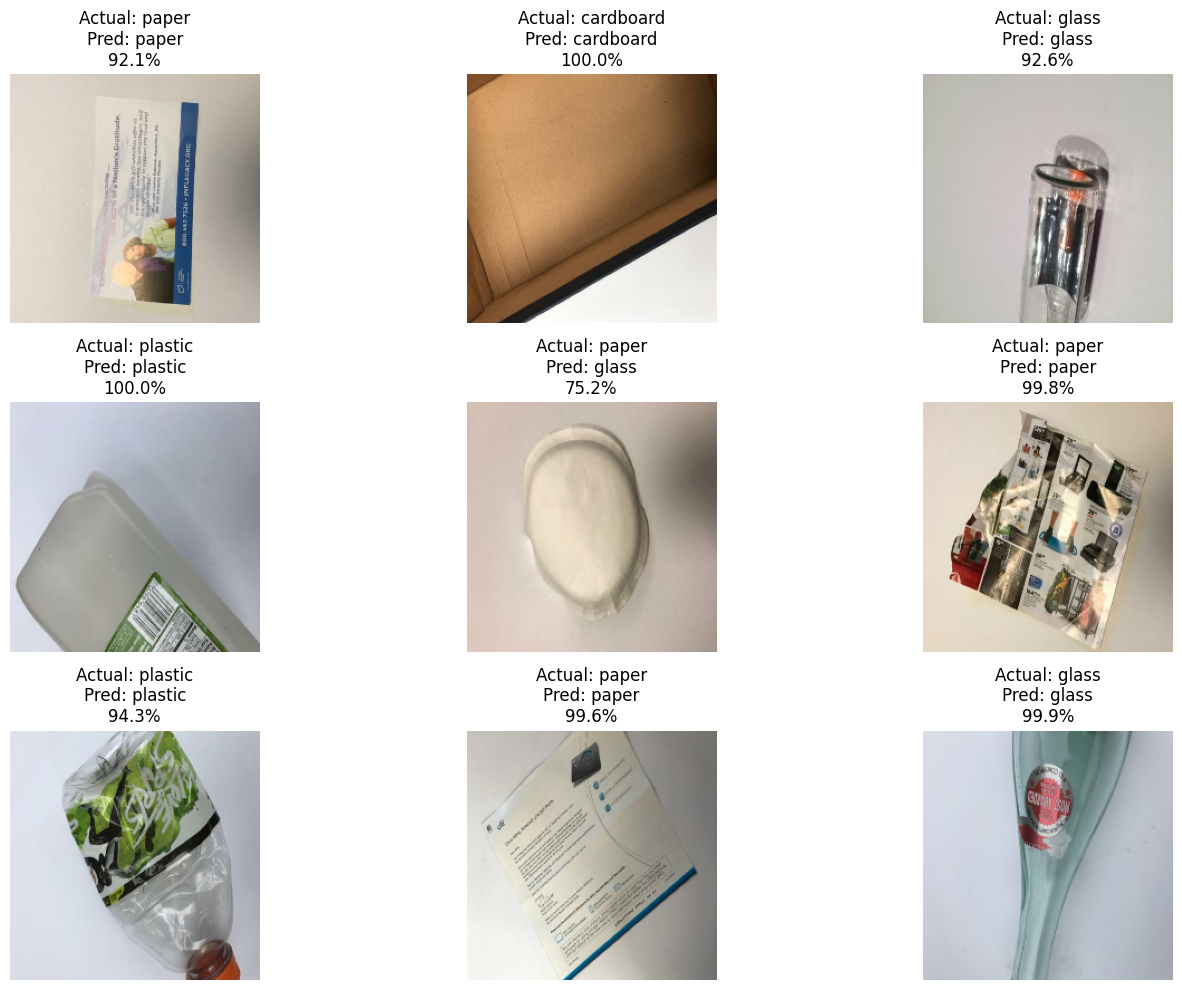

In [34]:
# Display Random Predictions

import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(15,10))

for images, labels in val_ds.take(1):
    predictions = model.predict(images, verbose=0)

    for i in range(9):
        plt.subplot(3,3,i+1)

        plt.imshow(images[i].numpy().astype("uint8"))

        actual = class_names[np.argmax(labels[i])]
        predicted = class_names[np.argmax(predictions[i])]
        confidence = np.max(predictions[i])*100

        plt.title(f"Actual: {actual}\nPred: {predicted}\n{confidence:.1f}%")

        plt.axis("off")

plt.tight_layout()
plt.show()

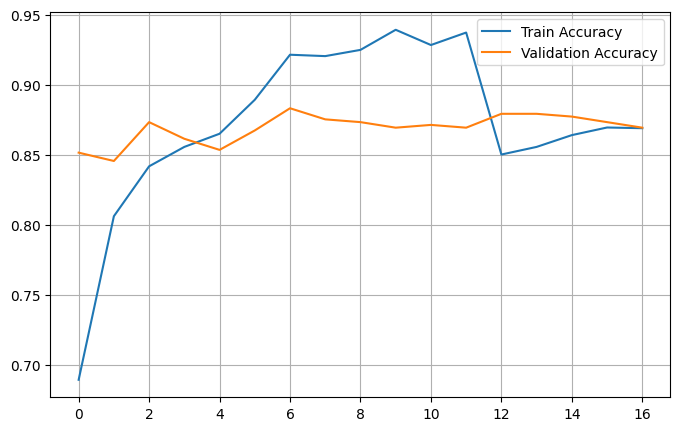

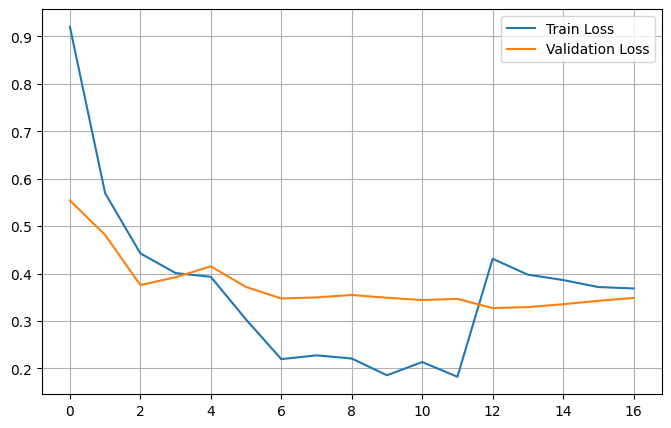

In [35]:
# Save Training Graphs

import matplotlib.pyplot as plt

# Accuracy
plt.figure(figsize=(8,5))
plt.plot(train_acc,label="Train Accuracy")
plt.plot(val_acc,label="Validation Accuracy")
plt.legend()
plt.grid(True)

plt.savefig("/content/drive/MyDrive/Garbage-Classification/outputs/accuracy.png")

plt.show()

# Loss
plt.figure(figsize=(8,5))
plt.plot(train_loss,label="Train Loss")
plt.plot(val_loss,label="Validation Loss")
plt.legend()
plt.grid(True)

plt.savefig("/content/drive/MyDrive/Garbage-Classification/outputs/loss.png")

plt.show()

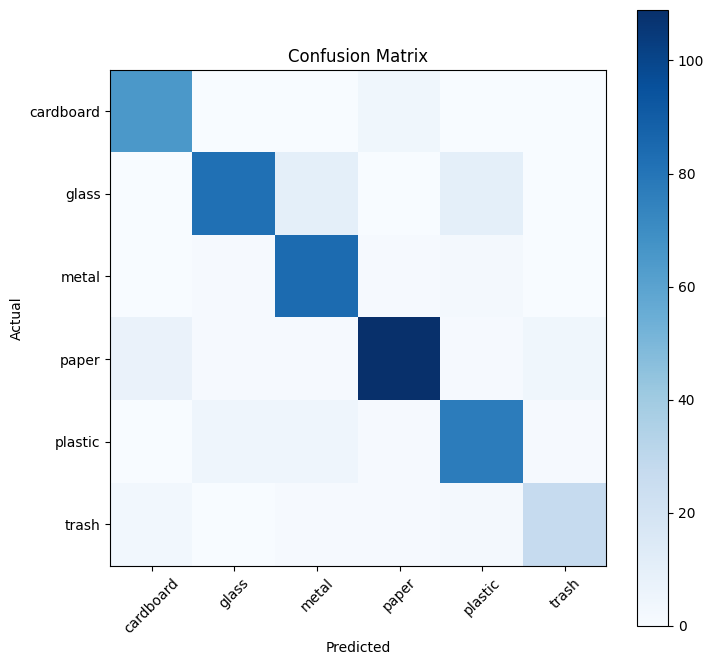

In [36]:
# Save Confusion Matrix

plt.figure(figsize=(8,8))
plt.imshow(cm,cmap="Blues")

plt.xticks(np.arange(len(class_names)),class_names,rotation=45)
plt.yticks(np.arange(len(class_names)),class_names)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.colorbar()

plt.savefig("/content/drive/MyDrive/Garbage-Classification/outputs/confusion_matrix.png")

plt.show()

In [37]:
# Final Project Summary

print("="*60)
print(" Garbage Classification Project")
print("="*60)

print(f"Model               : EfficientNetB0")
print(f"Classes             : {class_names}")
print(f"Training Images     : 2022")
print(f"Validation Images   : 505")
print(f"Validation Accuracy : {max(val_acc)*100:.2f}%")
print(f"TensorFlow Version  : {tf.__version__}")

print("\nModel saved successfully.")

print("="*60)

 Garbage Classification Project
Model               : EfficientNetB0
Classes             : ['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']
Training Images     : 2022
Validation Images   : 505
Validation Accuracy : 88.32%
TensorFlow Version  : 2.20.0

Model saved successfully.
